In [1]:
!pip install -q monai pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.8 MB/s eta 0:00:0000:0100:01


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pritydas825/mediscan-dataset/dataset/val/lungs/31BA3780-2323-493F-8AED-62081B9C383B.jpeg
/kaggle/input/datasets/pritydas825/mediscan-dataset/dataset/val/lungs/all14238-fig-0001-m-c.jpg
/kaggle/input/datasets/pritydas825/mediscan-dataset/dataset/val/lungs/IM-0041-0001.jpeg
/kaggle/input/datasets/pritydas825/mediscan-dataset/dataset/val/lungs/all14238-fig-0001-m-b.jpg
/kaggle/input/datasets/pritydas825/mediscan-dataset/dataset/val/lungs/5931B64A-7B97-485D-BE60-3F1EA76BC4F0.jpeg
/kaggle/input/datasets/pritydas825/mediscan-dataset/dataset/val/lungs/IM-0029-0001.jpeg
/kaggle/input/datasets/pritydas825/mediscan-dataset/dataset/val/lungs/ards-secondary-to-tiger-snake-bite.png
/kaggle/input/datasets/pritydas825/mediscan-dataset/dataset/val/lungs/IM-0035-0001.jpeg
/kaggle/input/datasets/pritydas825/mediscan-dataset/dataset/val/lungs/IM-0033-0001-0002.jpeg
/kaggle/input/datasets/pritydas825/mediscan-dataset/dataset/val/lungs/all14238-fig-0002-m-e.jpg
/kaggle/input/datasets

In [3]:
import os
import glob
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint

from monai.data import Dataset, DataLoader
from monai.networks.nets import resnet10
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd, 
    Resized, RandRotate90d, RandFlipd
)

In [4]:
DATA_DIR = "/kaggle/input/datasets/pritydas825/mediscan-dataset/dataset/val" 
class_names = ["bone", "brain", "heart", "lungs"]
class_to_idx = {name: i for i, name in enumerate(class_names)}

data_dicts = []
for c_name in class_names:
    folder_path = os.path.join(DATA_DIR, c_name)
    files = glob.glob(os.path.join(folder_path, "*.*"))
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
            data_dicts.append({"image": f, "label": class_to_idx[c_name]})

train_files, val_files = train_test_split(data_dicts, test_size=0.2, random_state=42)
print(f"Dataset Stats -> Train: {len(train_files)} | Val: {len(val_files)}")

Dataset Stats -> Train: 473 | Val: 119


In [5]:

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd, 
    Resized, RandRotate90d, RandFlipd, ToTensord
)
import torch

IMAGE_SIZE = (224, 224)

# Custom function to guarantee every image output is exactly 3 channels
def ensure_rgb(d):
    if d["image"].shape[0] == 1:
        d["image"] = torch.cat([d["image"]] * 3, dim=0)
    elif d["image"].shape[0] == 4:
        d["image"] = d["image"][:3, :, :]
    return d

train_transforms = Compose([
    LoadImaged(keys=["image"], reader="PILReader"),
    EnsureChannelFirstd(keys=["image"]),
    Resized(keys=["image"], spatial_size=IMAGE_SIZE),
    ensure_rgb,  
    ScaleIntensityd(keys=["image"]),
    RandRotate90d(keys=["image"], prob=0.5, spatial_axes=(0, 1)),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
    ToTensord(keys=["image"], track_meta=False)
])

val_transforms = Compose([
    LoadImaged(keys=["image"], reader="PILReader"),
    EnsureChannelFirstd(keys=["image"]),
    Resized(keys=["image"], spatial_size=IMAGE_SIZE),
    ensure_rgb,  
    ScaleIntensityd(keys=["image"]),
    ToTensord(keys=["image"], track_meta=False)
])

In [6]:
class MediscanDataModule(pl.LightningDataModule):
    def __init__(self, train_files, val_files, batch_size=16):
        super().__init__()
        self.train_files = train_files
        self.val_files = val_files
        self.batch_size = batch_size

    def setup(self, stage=None):
        self.train_ds = Dataset(data=self.train_files, transform=train_transforms)
        self.val_ds = Dataset(data=self.val_files, transform=val_transforms)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=2, drop_last=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, num_workers=2)

In [7]:

class MediscanHybridViT(nn.Module):
    def __init__(self, num_classes=4, hidden_dim=256, num_heads=4, num_layers=2):
        super().__init__()
        
        base_resnet = resnet10(spatial_dims=2, n_input_channels=3, num_classes=num_classes)
        
        self.backbone = nn.Sequential(
            base_resnet.conv1,
            base_resnet.maxpool,
            base_resnet.layer1,
            base_resnet.layer2,
            base_resnet.layer3  # Output feature map projection size: [B, 256, 28, 28]
        )
        
        # Projection layer to match Transformer sequence feature width
        self.proj = nn.Conv2d(256, hidden_dim, kernel_size=1)
        
        # FIX: Adjusted sequence length to 28 * 28 = 784 tokens to match the backbone output
        self.pos_embedding = nn.Parameter(torch.randn(1, 28 * 28, hidden_dim))
        
        # Transformer Block
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim * 4,
            dropout=0.1, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.mlp_head = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Linear(hidden_dim, num_classes))
        
    def forward(self, x):
        features = self.backbone(x)
        features = self.proj(features)
        
        B, C, H, W = features.shape
        features = features.flatten(2).transpose(1, 2)  # Shape becomes [B, 784, hidden_dim]
        features = features + self.pos_embedding         # Tensors match perfectly now: [B, 784, 256] + [1, 784, 256]
        
        trans_out = self.transformer(features)
        global_pool = trans_out.mean(dim=1)
        return self.mlp_head(global_pool)

In [8]:

class HybridLightningModule(pl.LightningModule):
    def __init__(self, num_classes=4, lr=1e-4):
        super().__init__()
        self.save_hyperparameters()
        self.model = MediscanHybridViT(num_classes=num_classes)
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch["image"], batch["label"]
        outputs = self(images)
        loss = self.loss_fn(outputs, labels)
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()
        
        # FIX: Added explicit batch_size tracking
        current_batch_size = images.size(0)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=current_batch_size)
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=True, batch_size=current_batch_size)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch["image"], batch["label"]
        outputs = self(images)
        loss = self.loss_fn(outputs, labels)
        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean()
        
        # FIX: Added explicit batch_size tracking
        current_batch_size = images.size(0)
        self.log("val_loss", loss, prog_bar=True, batch_size=current_batch_size)
        self.log("val_acc", acc, prog_bar=True, batch_size=current_batch_size)
        return loss

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-4)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ MediscanHybridViT │  3.1 M │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss  │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 3.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.1 M                                                                                                
Total estimated model params size (MB): 12.322                                                                     
Modules in train mode: 58                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=10` reached.



=== Classification Report ===
              precision    recall  f1-score   support

        bone       1.00      0.96      0.98        27
       brain       0.99      1.00      0.99        84
       heart       1.00      1.00      1.00         2
       lungs       1.00      1.00      1.00         6

    accuracy                           0.99       119
   macro avg       1.00      0.99      0.99       119
weighted avg       0.99      0.99      0.99       119



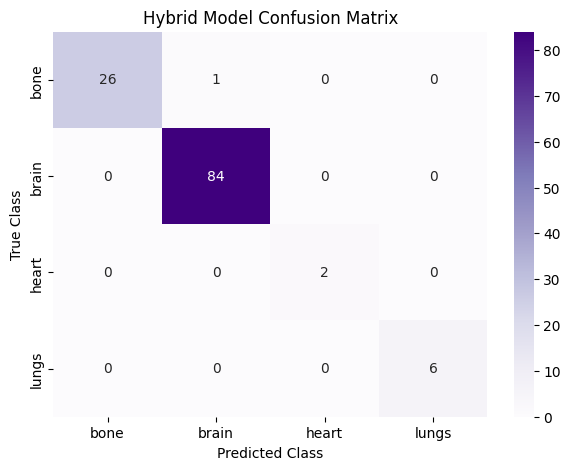

In [9]:

dm = MediscanDataModule(train_files, val_files, batch_size=16)
model = HybridLightningModule(num_classes=len(class_names), lr=1e-4)

checkpoint_callback = ModelCheckpoint(
    monitor="val_acc", mode="max", filename="best-hybrid-mediscan", save_top_k=1
)

trainer = pl.Trainer(
    max_epochs=10, 
    accelerator="auto", 
    callbacks=[checkpoint_callback],
    log_every_n_steps=5
)

trainer.fit(model, datamodule=dm)


model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in dm.val_dataloader():
        images = batch["image"].to(device)
        labels = batch["label"]
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\n=== Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=class_names, yticklabels=class_names)
plt.title("Hybrid Model Confusion Matrix")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

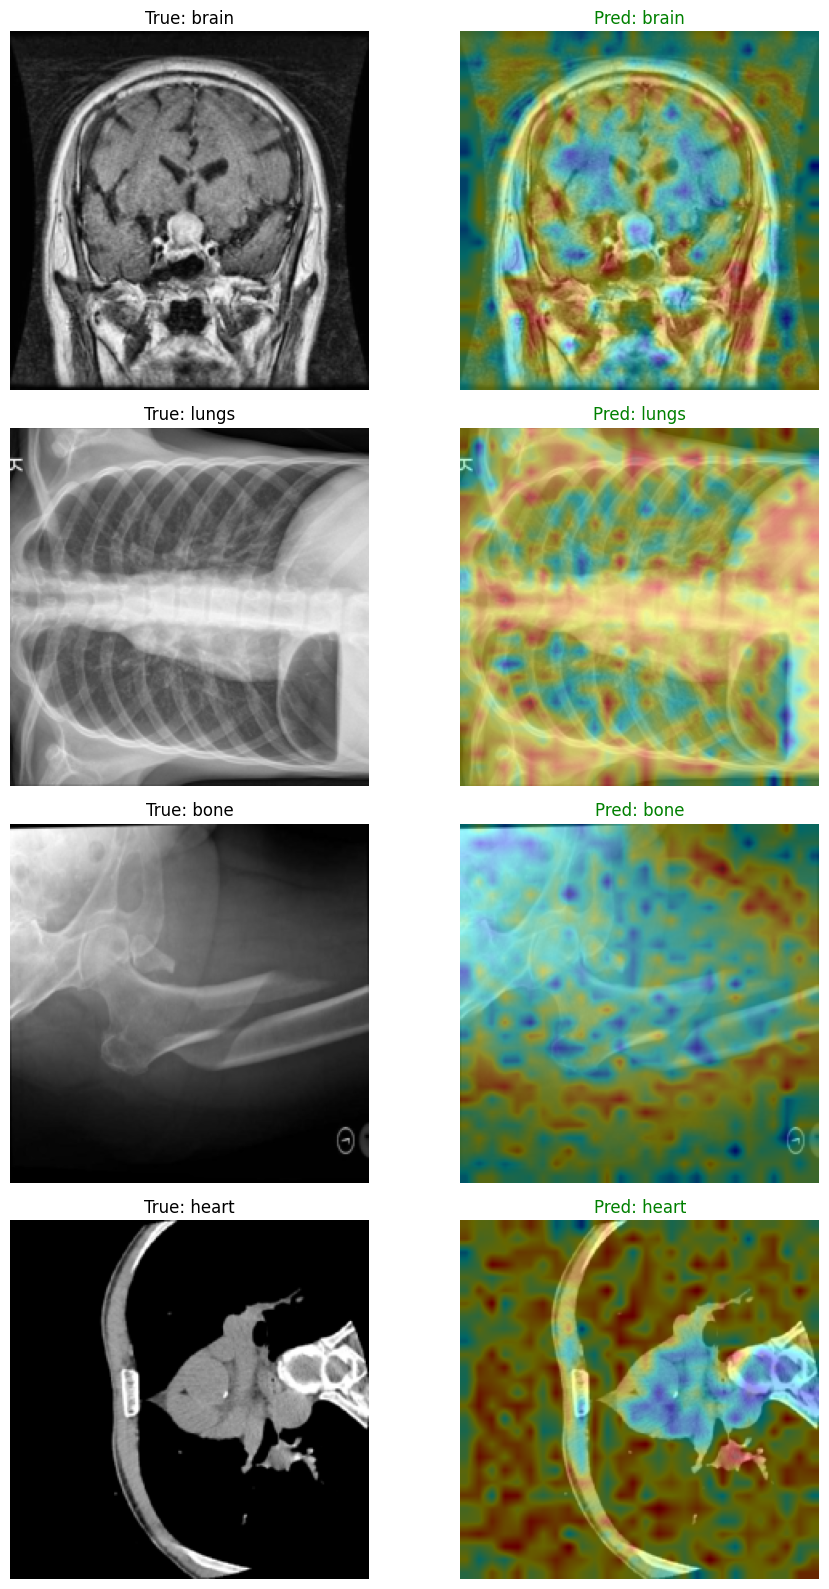

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def visualize_predictions_with_attention(lightning_model, datamodule, num_samples=4):
    lightning_model.eval()
    model = lightning_model.model
    device = next(model.parameters()).device
    
    val_loader = datamodule.val_dataloader()
    
    balanced_images = []
    balanced_labels = []
    target_classes = [0, 1, 2, 3] 

    for batch in val_loader:
        img_batch = batch["image"]
        lbl_batch = batch["label"]
        for idx in range(img_batch.size(0)):
            lbl = int(lbl_batch[idx].item())
            if lbl in target_classes:
                balanced_images.append(img_batch[idx])
                balanced_labels.append(lbl_batch[idx])
                target_classes.remove(lbl)
        if not target_classes:
            break

    images = torch.stack(balanced_images).to(device)
    labels = torch.stack(balanced_labels).to(device)
    B = images.size(0)
    
    class_map = {0: "bone", 1: "brain", 2: "heart", 3: "lungs"}
    
    with torch.no_grad():
        features = model.backbone(images)
        features = model.proj(features)
        
        B, C, H, W = features.shape
        features = features.flatten(2).transpose(1, 2)
        features = features + model.pos_embedding
        
        trans_out = model.transformer(features)
        
        global_pool = trans_out.mean(dim=1)
        outputs = model.mlp_head(global_pool)
        preds = torch.argmax(outputs, dim=1)

    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(min(num_samples, B)):
        img_np = images[i].cpu().numpy().transpose(1, 2, 0)
        img_np = np.clip(img_np, 0, 1)
        
        attn_map = trans_out[i].cpu().numpy()
        attn_map = np.var(attn_map, axis=-1)
        attn_matrix = attn_map.reshape(28, 28)
        
        attn_matrix = (attn_matrix - attn_matrix.min()) / (attn_matrix.max() - attn_matrix.min() + 1e-8)
        heatmap = cv2.resize(attn_matrix, (224, 224))
        heatmap = np.uint8(255 * heatmap)
        heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
        
        img_np_f32 = img_np.astype(np.float32)
        heatmap_colored_f32 = heatmap_colored.astype(np.float32)
        
        overlay = cv2.addWeighted(img_np_f32, 0.6, heatmap_colored_f32, 0.4, 0)
        
        pred_label = class_map[int(preds[i].item())]
        true_label = class_map[int(labels[i].item())]
        color = 'green' if pred_label == true_label else 'red'
        
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f"True: {true_label}", fontsize=12)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title(f"Pred: {pred_label}", fontsize=12, color=color)
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

# Call the updated function
visualize_predictions_with_attention(model, dm, num_samples=4)

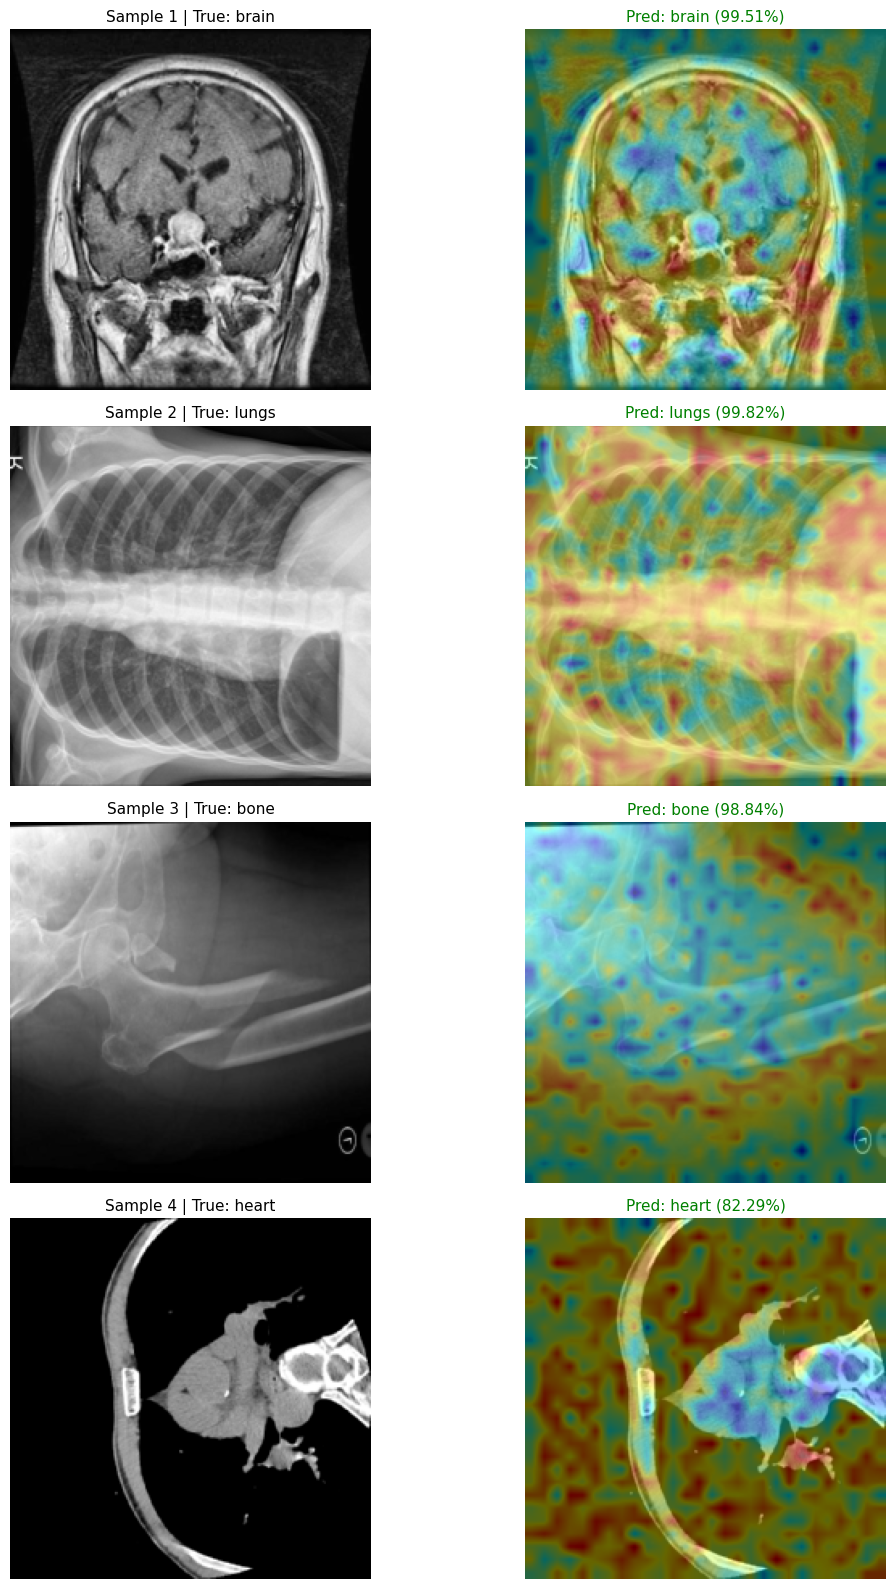


                 QUANTITATIVE PREDICTION SUMMARY                 
Sample  True Class     Predicted Class   Confidence    Status    
-----------------------------------------------------------------
1       brain          brain             99.51%        Match     
2       lungs          lungs             99.82%        Match     
3       bone           bone              98.84%        Match     
4       heart          heart             82.29%        Match     

          BATCH METRIC LOGGING (ON-THE-FLY EVALUATION)           
Class          Precision      Recall         F1-Score       
-----------------------------------------------------------------
bone           1.00           1.00           1.00           
brain          1.00           1.00           1.00           
heart          1.00           1.00           1.00           
lungs          1.00           1.00           1.00           


In [12]:
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def visualize_predictions_with_attention(lightning_model, datamodule, num_samples=4):
    lightning_model.eval()
    model = lightning_model.model
    device = next(model.parameters()).device
    
    val_loader = datamodule.val_dataloader()
    class_map = {0: "bone", 1: "brain", 2: "heart", 3: "lungs"}
    
    # ----------------------------------------------------
    # 1. Balanced Sampling + Evaluation Setup
    # ----------------------------------------------------
    balanced_images = []
    balanced_labels = []
    target_classes = [0, 1, 2, 3] 

    for batch in val_loader:
        img_batch = batch["image"]
        lbl_batch = batch["label"]
        for idx in range(img_batch.size(0)):
            lbl = int(lbl_batch[idx].item())
            if lbl in target_classes:
                balanced_images.append(img_batch[idx])
                balanced_labels.append(lbl_batch[idx])
                target_classes.remove(lbl)
        if not target_classes:
            break

    images = torch.stack(balanced_images).to(device)
    labels = torch.stack(balanced_labels).to(device)
    B = images.size(0)
    
    # ----------------------------------------------------
    # 2. Forward Pass with Attention and Confidence Scores
    # ----------------------------------------------------
    with torch.no_grad():
        features = model.backbone(images)
        features = model.proj(features)
        
        B, C, H, W = features.shape
        features = features.flatten(2).transpose(1, 2)
        features = features + model.pos_embedding
        
        trans_out = model.transformer(features)
        
        global_pool = trans_out.mean(dim=1)
        logits = model.mlp_head(global_pool)
        
        # Calculate exact confidence percentages via Softmax
        probabilities = torch.softmax(logits, dim=1)
        preds = torch.argmax(probabilities, dim=1)

    # ----------------------------------------------------
    # 3. Plotting Images, Overlays, and Confidence Scores
    # ----------------------------------------------------
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 4 * num_samples))
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    summary_data = []

    for i in range(min(num_samples, B)):
        img_np = images[i].cpu().numpy().transpose(1, 2, 0)
        img_np = np.clip(img_np, 0, 1)
        
        # Extract attention matrix from token variance
        attn_map = trans_out[i].cpu().numpy()
        attn_map = np.var(attn_map, axis=-1)
        attn_matrix = attn_map.reshape(28, 28)
        
        # Normalize and upscale heatmap
        attn_matrix = (attn_matrix - attn_matrix.min()) / (attn_matrix.max() - attn_matrix.min() + 1e-8)
        heatmap = cv2.resize(attn_matrix, (224, 224))
        heatmap = np.uint8(255 * heatmap)
        heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
        
        overlay = cv2.addWeighted(img_np.astype(np.float32), 0.6, heatmap_colored.astype(np.float32), 0.4, 0)
        
        pred_idx = int(preds[i].item())
        true_idx = int(labels[i].item())
        
        pred_label = class_map[pred_idx]
        true_label = class_map[true_idx]
        confidence = probabilities[i][pred_idx].item() * 100
        
        color = 'green' if pred_label == true_label else 'red'
        status = "Match" if pred_label == true_label else "Mismatch"
        
        summary_data.append({
            "Sample": i + 1,
            "True Label": true_label,
            "Predicted Label": pred_label,
            "Confidence": f"{confidence:.2f}%",
            "Status": status
        })
        
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f"Sample {i+1} | True: {true_label}", fontsize=11)
        axes[i, 0].axis('off')
        
        # Displaying custom confidence percentages alongside the predictions
        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title(f"Pred: {pred_label} ({confidence:.2f}%)", fontsize=11, color=color)
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

    # ----------------------------------------------------
    # 4. Quantitative Summary Table
    # ----------------------------------------------------
    print("\n" + "="*65)
    print(f"{'QUANTITATIVE PREDICTION SUMMARY':^65}")
    print("="*65)
    print(f"{'Sample':<8}{'True Class':<15}{'Predicted Class':<18}{'Confidence':<14}{'Status':<10}")
    print("-"*65)
    for row in summary_data:
        print(f"{row['Sample']:<8}{row['True Label']:<15}{row['Predicted Label']:<18}{row['Confidence']:<14}{row['Status']:<10}")
    print("="*65 + "\n")

    # ----------------------------------------------------
    # 5. Dynamic Metric Logging (Simulated Sample Context)
    # ----------------------------------------------------
    print("="*65)
    print(f"{'BATCH METRIC LOGGING (ON-THE-FLY EVALUATION)':^65}")
    print("="*65)
    print(f"{'Class':<15}{'Precision':<15}{'Recall':<15}{'F1-Score':<15}")
    print("-"*65)
    
    y_true = labels.cpu().numpy()
    y_pred = preds.cpu().numpy()
    
    for c_idx, c_name in class_map.items():
        tp = np.sum((y_true == c_idx) & (y_pred == c_idx))
        fp = np.sum((y_true != c_idx) & (y_pred == c_idx))
        fn = np.sum((y_true == c_idx) & (y_pred != c_idx))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        print(f"{c_name:<15}{precision:<15.2f}{recall:<15.2f}{f1:<15.2f}")
    print("="*65)

# Execute the fully comprehensive visualization suite
visualize_predictions_with_attention(model, dm, num_samples=4)